In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf 
from statsmodels.iolib.summary2 import summary_col

### First Task: Relationship between religiosity and economic development
I estimate the  relationship between intensity of religiosity at the local level and economic development during the Second Industrial Revolution, where the religiosity is measured by the share of refractory clergy.

The dataset used contains information contains department-level information before and after the Second Industrial Revolution.

In [2]:
def var_labels(data_path):
    stata_reader = pd.read_stata(data_path, iterator=True)
    labels_dict = stata_reader.variable_labels()
    data_dictionary = pd.DataFrame(columns=["Variable", "Label"], 
                                   data=list(labels_dict.items()))
    return data_dictionary

In [3]:
dept_data  = pd.read_stata("Data/1.dept_dataset.dta")
dept_labels = var_labels("Data/1.dept_dataset.dta")

We can then create a DataFrame from the labels dictionary. Through Data Wrangles plugin in VScode we can replicate a Stata-like experience when it comes to exploring variables and their labels. Just go in the Jupyter tab, and click on the Dataframe created below.

I first replicate Table 2 from the paper, which shows the association between the intensity of religiosity on different variable before and after the second industrial revolution.

In [4]:
model1 = smf.ols(formula="share_ind_work1901 ~ share_refractory", data=dept_data).fit(cov_type="HC1")
model2 = smf.ols(formula="machines_pc ~ share_refractory", data=dept_data).fit(cov_type="HC1")
model3 = smf.ols(formula="share_ind_work1866 ~ share_refractory", data=dept_data).fit(cov_type="HC1")
model4 = smf.ols(formula="steam_engine_pc ~ share_refractory", data=dept_data).fit(cov_type="HC1")

table2 = summary_col([model1, model2, model3, model4], 
            stars=True, 
            float_format="%.3f",
            info_dict={ "Obs" : lambda x : f"{x.nobs:.0f}"},
            model_names=["Share ind. workers 1901", "Machines pc, 1891", "Share ind. workers 1866", "Steam eng. pc, 1840"],
            regressor_order=["share_refractory"],
            drop_omitted=True,
            )
table2

,Share ind. workers 1901,"Machines pc, 1891",Share ind. workers 1866,"Steam eng. pc, 1840"
share_refractory,-0.146*,-0.863**,-0.027,0.029
,(0.085),(0.397),(0.080),(0.052)
R-squared,0.037,0.062,0.001,0.008
R-squared Adj.,0.025,0.050,-0.011,-0.005
Obs,83,83,83,81


Table 3 includes sevaral controls

In [5]:
regressors1 = ["share_refractory","lnpop1901", "mean_lntemp", "mean_lnprec", "wheat_suit","lnproto_ind", "lndist_Paris", "pays_elections", "lnsub_dept", "enrol_rate1891"]
regressors2 = ["share_refractory","lnpop1891", "mean_lntemp", "mean_lnprec", "wheat_suit","lnproto_ind", "lndist_Paris", "pays_elections", "lnsub_dept", "enrol_rate1881"]

In [6]:
model1 = smf.ols(formula=f"share_ind_work1901 ~ {"+".join(regressors1[:-4])}", data=dept_data).fit(cov_type="HC1")
model2 = smf.ols(formula=f"machines_pc ~ {"+".join(regressors2[:-4])}", data=dept_data).fit(cov_type="HC1")
model3 = smf.ols(formula=f"share_ind_work1901 ~ {"+".join(regressors1[:-2])}", data=dept_data).fit(cov_type="HC1")
model4 = smf.ols(formula=f"machines_pc ~ {"+".join(regressors2[:-2])}", data=dept_data).fit(cov_type="HC1")
model5 = smf.ols(formula=f"share_ind_work1901 ~ {"+".join(regressors1)}", data=dept_data).fit(cov_type="HC1")
model6 = smf.ols(formula=f"machines_pc ~ {"+".join(regressors2)}", data=dept_data).fit(cov_type="HC1")

reg_order = ["share_refractory","lnpop1901","lnpop1891", "mean_lntemp", "mean_lnprec", "wheat_suit","lnproto_ind","lndist_Paris", "pays_elections", "lnsub_dept", "enrol_rate1881"]

In [7]:
summary_col([model1, model2, model3, model4, model5, model6], 
            float_format="%.3f", 
            stars=True, 
            regressor_order=reg_order,
            drop_omitted=True,
            info_dict= {"Obs" : lambda x : f"{x.nobs:.0f}"},
            model_names=["Share ind.workers, 1901", "Machinespc, 1891"] * 3)

,"Share ind.workers, 1901 I","Machinespc, 1891 I","Share ind.workers, 1901 II","Machinespc, 1891 II","Share ind.workers, 1901 III","Machinespc, 1891 III"
share_refractory,-0.187***,-1.382***,-0.173**,-1.277***,-0.149**,-1.133***
,(0.059),(0.294),(0.077),(0.304),(0.073),(0.297)
lnpop1901,0.159***,,0.137***,,0.131***,
,(0.025),,(0.036),,(0.041),
lnpop1891,,0.612***,,0.331,,0.260
,,(0.145),,(0.209),,(0.228)
mean_lntemp,-0.030,0.252,-0.028,0.271,0.056,0.462
,(0.085),(0.345),(0.086),(0.312),(0.102),(0.331)
mean_lnprec,-0.151**,-0.786**,-0.128*,-0.542*,-0.142**,-0.541**
,(0.062),(0.331),(0.067),(0.277),(0.061),(0.258)


### Second Task: Driving mechanism behind the relationship
I reproduce Table 7 columns 4 and 7 and Figure 2 from the paper. The table indicates that cantons with higher levels of religiosity have experienced a greater increase in the proportion of Catholic schools. Figure 2 illustrates the evolution of the share of Catholic and secular schools in both the private and public sectors.

In [8]:
cantons_data = pd.read_stata("Data/2b.canton_dataset_schooling.dta")
cantons_labels = var_labels("Data/2b.canton_dataset_schooling.dta")

schools_data = pd.read_stata("Data/cath_sec_schools.dta")
schools_labels = var_labels("Data/cath_sec_schools.dta")

The dependent variables are the share of catholic schools and the growth share of catholic schools, and standard errors are clustered at the district level.

In [9]:
regressors1 = ["share_refractory", "lnpopulation","lnstud_ps", "lnschools_total", "department_id"] 
regressors2 = ["share_refractory", "gr_population", "share_cath_schools_l", "lnstud_ps_l", "lnschools_total_l", "wheat_suit", "lndist_Paris", "lnsubs", "department_id"]

When I initially run the regression, statsmodels raised a value error due to a mismatch between the number of rows used in the estimation and the length of the clustering column (district_id) specified in cov_kdws. This happens because statsmodels automatically drops any rows that presents missing values for the variables included in the equation, but it doesn't apply the same filter to the clustering variables.

To solve this, I retrived the indices of the rows retained by the model, and used them to filter the district_id column before fitting.

In [10]:
model1 = smf.ols(formula=f"share_cath_schools ~ + {"+".join(regressors1[:-1])} + C(department_id)", data=cantons_data.query("year == 1894"))
clusters = cantons_data.query("year == 1894").loc[model1.data.row_labels, "district_id"]
col4 = model1.fit(cov_type="cluster", cov_kwds={"groups" : clusters})


model2= smf.ols(formula=f"gr_share_cath_schools ~ + {"+".join(regressors2[:-1])} + C(department_id)", data=cantons_data.query("year==1894")) 
clusters = cantons_data.query("year == 1894").loc[model2.data.row_labels, "district_id"]
col7 = model2.fit(cov_type="cluster", cov_kwds={"groups" : clusters})

In [11]:
summary_col([col4, col7],
            regressor_order=["share_refractory"], 
            drop_omitted=True,
            stars=True,
            float_format="%.3f",
            info_dict={"N" : lambda x : f"{x.nobs:.0f}"},
            model_names=["Share Catholic Schools 1894", "Growth Share Catholic Schools 1873-1894"])

,Share Catholic Schools 1894,Growth Share Catholic Schools 1873-1894
share_refractory,0.099***,0.142**
,(0.017),(0.067)
R-squared,0.618,0.277
R-squared Adj.,0.601,0.241
N,1891,1613


In [12]:
schools_data = schools_data.assign(
    tot_cath_schools = schools_data["schools_priv_cath"] + schools_data["schools_pub_cath"],
    tot_lay_schools =
schools_data["schools_priv_lay"] + schools_data["schools_pub_lay"]
)

schools_data_years = schools_data.groupby("year").sum().reset_index()
schools_data_years.columns = ["year", "department_id", "Public Secular Schools", "Public Catholic Schools",
                                          "Private Secular Schools", "Private Catholic Schools",
                                          "Total Catholic Schools", "Total Secular Schools"]
schools_data_years

,year,department_id,Public Secular Schools,Public Catholic Schools,Private Secular Schools,Private Catholic Schools,Total Catholic Schools,Total Secular Schools
0,1866,3612,38196.0,10071.0,9706.0,6533.0,16604.0,47902.0
1,1871,3612,42144.0,11523.0,7301.0,6387.0,17910.0,49445.0
2,1876,3612,43726.0,12620.0,5767.0,6558.0,19178.0,49493.0
3,1881,3612,49445.0,10742.0,4413.0,8001.0,18743.0,53858.0
4,1886,3612,55128.0,8722.0,3881.0,9351.0,18073.0,59009.0
5,1891,3612,57205.0,6395.0,3376.0,11423.0,17818.0,60581.0
6,1896,3612,58639.0,5143.0,2796.0,12766.0,17909.0,61435.0
7,1901,3612,60586.0,3404.0,2516.0,14301.0,17705.0,63102.0


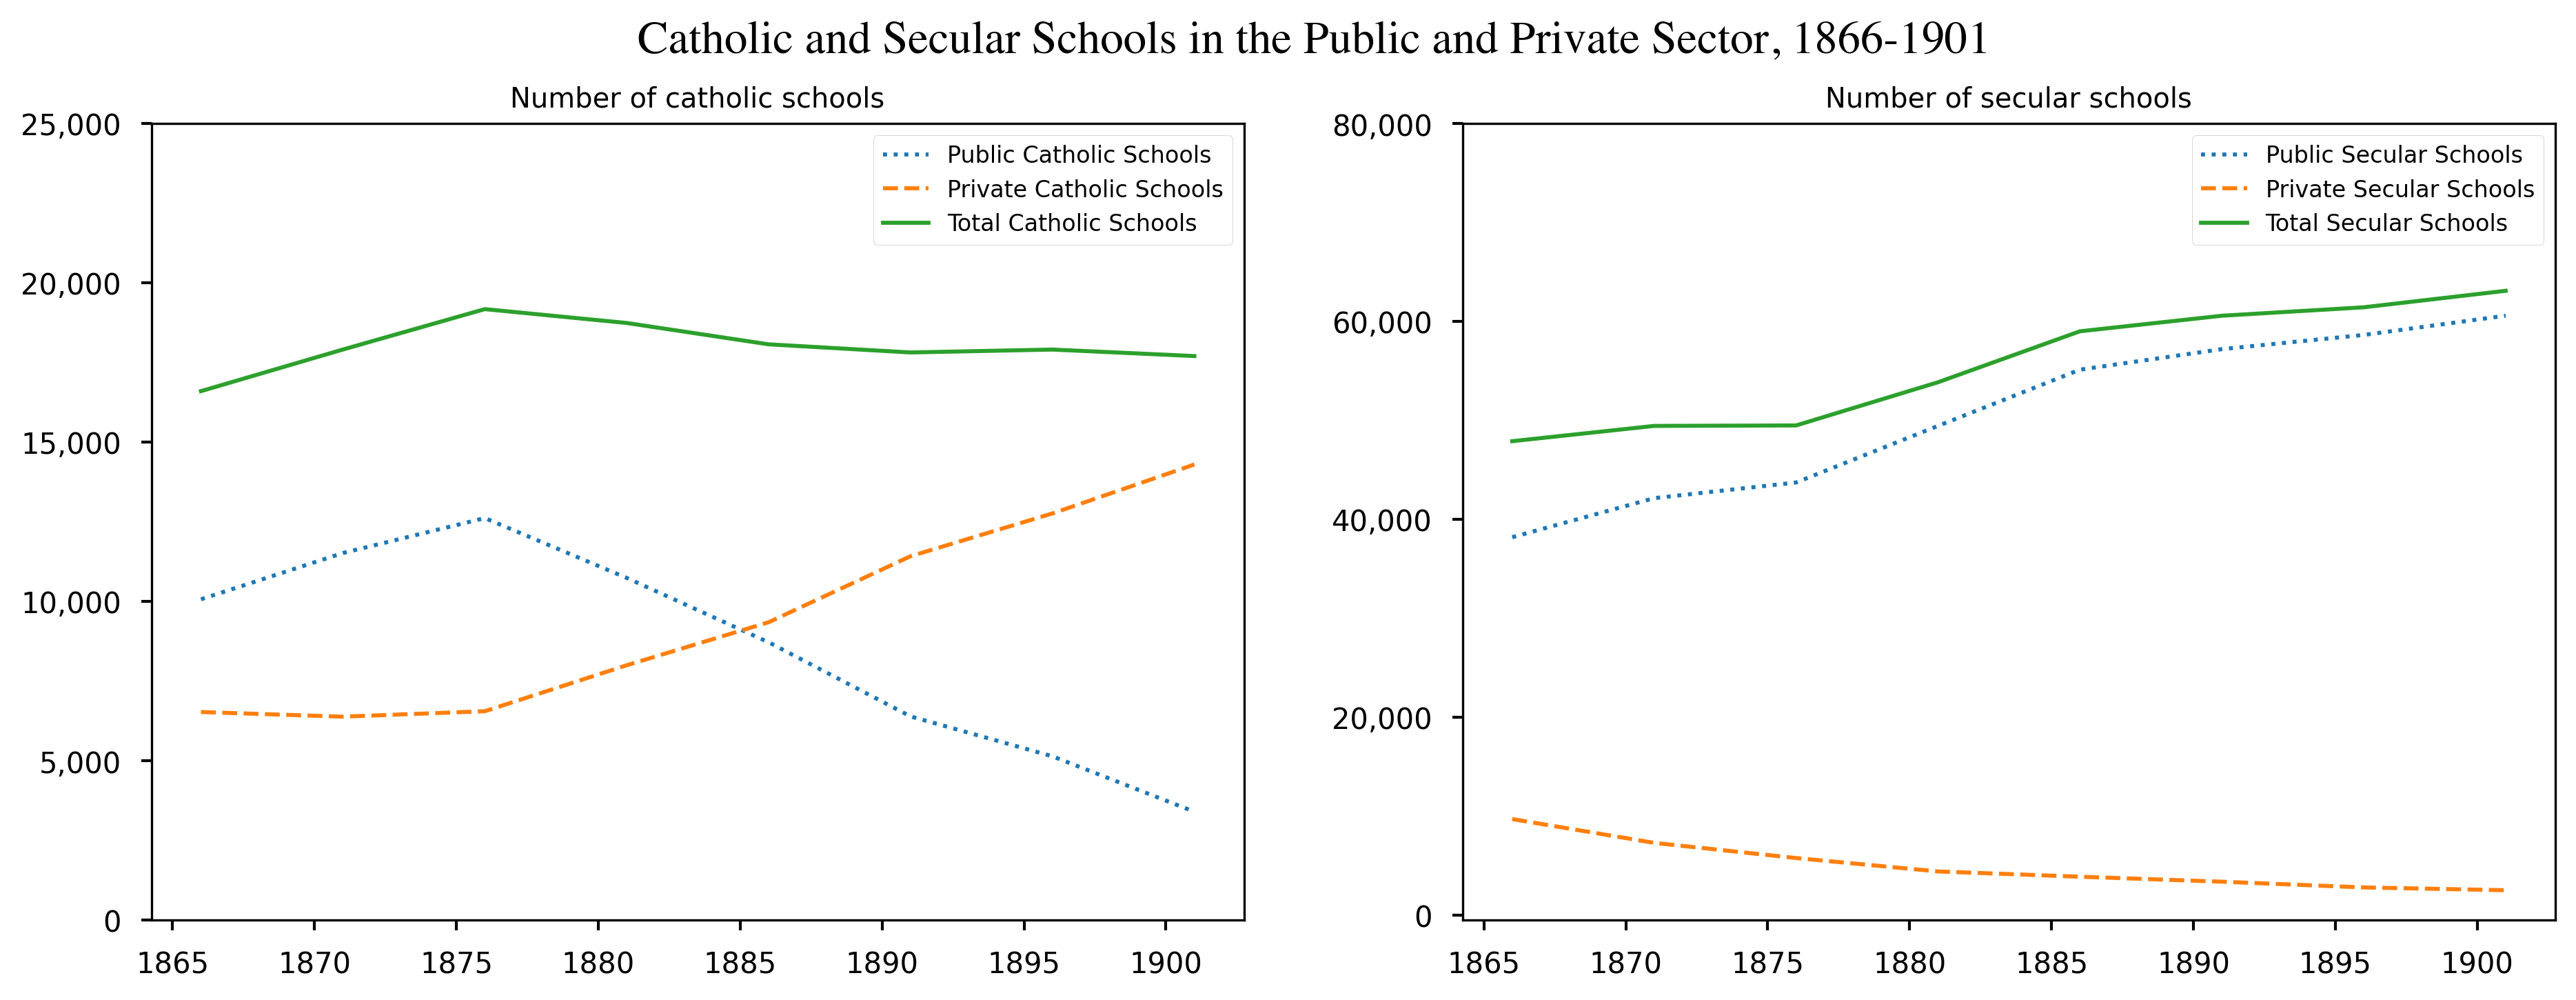

In [20]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15,5), dpi=300)
plt.style.use("seaborn-v0_8-paper")
line_styles = ["dotted", "dashed", "solid"]


for key,val in dict(zip(schools_data_years.iloc[:, np.r_[3,5,6]].columns, line_styles)).items(): #this selects only catholic schools columns
    ax1.plot(schools_data_years["year"], 
             schools_data_years[key],
             label=key,
             ls = val)

for key,val in dict(zip(schools_data_years.iloc[:, np.r_[2,4,7]].columns, line_styles)).items(): #this selects only catholic schools columns
    ax2.plot(schools_data_years["year"], 
                schools_data_years[key],
                label=key,
                ls = val)

ax1.set_yticks(np.arange(0,25001, 5000))
ax2.set_yticks(np.arange(0,80001, 20000))
ax1.legend()
ax2.legend()
ax1.set_title("Number of catholic schools")
ax2.set_title("Number of secular schools")
plt.suptitle("Catholic and Secular Schools in the Public and Private Sector, 1866-1901",
             fontsize=16, fontfamily="Times")
ax1.yaxis.set_major_formatter("{x:,.0f}")
ax2.yaxis.set_major_formatter("{x:,.0f}")


plt.show()

### Task 3: Channels

In [14]:
dept_data
cohort_df = pd.read_stata("Data/3b.cohort_dataset.dta")
cohort_labels = var_labels("Data/3b.cohort_dataset.dta")

In [ ]:
controls = ["enrol_rate", "lnstud_ps", "lnschools_total"]
order = ["share_cath_schools", "share_cath_stud"]

reg1 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_schools +  + lnpop + C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))
               
reg2 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_schools + lnpop + {"+".join(controls)} + C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))
               
reg3 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_stud + lnpop +  C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))

reg4 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_stud + lnpop + {"+".join(controls)} + C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))

In [16]:
info = {"   Schooling controls" : lambda x: "✓" if "lnstud_ps" in x.model.exog_names else "",
        "  Department FE" : lambda x : "✓" if any("C(department_id)" in d for d in x.model.exog_names) else "",
        " Cohort FE" : lambda x  : "✓" if any("C(year)" in y for y in  x.model.exog_names) else "",
        "R2" : lambda x : f"{x.rsquared:.2f}",
        "Obs" : lambda x : f"{x.nobs:.0f}"}

table12 = summary_col([reg1, reg2, reg3, reg4],
            regressor_order=order,
            drop_omitted=True,
            float_format="%.3f",
            stars=True,
            info_dict=info,
            model_names=["(1)", "(2)", "(3)", "(4)"],
            include_r2=False)
table12.add_title("Religiously educated cohorts less likely to be employed in innovative sectors")
table12.add_text("Dependent variable: share of workers in innovative sectors")
table12

,(1),(2),(3),(4)
share_cath_schools,-0.384**,-0.381**,,
,(0.150),(0.154),,
share_cath_stud,,,-0.206*,-0.239**
,,,(0.118),(0.108)
Schooling controls,,✓,,✓
Department FE,✓,✓,✓,✓
Cohort FE,✓,✓,✓,✓
Obs,249,249,249,249
R2,0.97,0.97,0.97,0.97


In [17]:
controls = ["lnpop1871", "mean_lnprec", "mean_lntemp", "wheat_suit", "lnproto_ind", "lndist_Paris", "pays_elections", "enrol_rate1871", "lnsub_dept"]
info = {"  Controls" : lambda x : "✓"	if "lnpop1871" in x.model.exog_names else "",
        " R2" : lambda x : f"{x.rsquared:.2f}",
        "Obs" : lambda x : f"{x.nobs:.0f}"}

mod1 = smf.ols(formula="share_vac_needed ~ share_refractory", data=dept_data).fit(cov_type="HC1")
mod2 = smf.ols(formula=f"share_vac_needed ~ share_refractory + {"+".join(controls)}", data=dept_data).fit(cov_type="HC1")
mod3 = smf.ols(formula="fert_princeton_index ~ share_refractory", data=dept_data).fit(cov_type="HC1")
mod4 = smf.ols(formula=f"fert_princeton_index ~ share_refractory + {"+".join(controls)}", data=dept_data).fit(cov_type="HC1")


In [18]:
table13 = summary_col([mod1, mod2, mod3, mod4],
                      stars = True,
                      include_r2=False,
                      info_dict=info,
                      regressor_order=["share_refractory"],
                      drop_omitted=True,
                      float_format="%.3f",
                      model_names=["Share vaccinations 1871",
                                   "Share vaccinations 1871",
                                   "Fertiliy 1871",
                                   "Fertiliy 1871"])

table13.tables[0].rename(index={"share_refractory" : "Share Refractory"}, inplace=True)
table13

,Share vaccinations 1871 I,Share vaccinations 1871 II,Fertiliy 1871 I,Fertiliy 1871 II
Share Refractory,-0.248**,-0.260*,0.240***,0.197***
,(0.123),(0.145),(0.060),(0.045)
Controls,,✓,,✓
R2,0.06,0.20,0.20,0.66
Obs,66,62,83,79
